# Label Signal Boost Recipes

Use this notebook to rebuild stronger labels from the same candlestick images, then train on the new metadata.


In [2]:
!pip install -q yfinance transformers

In [3]:
import sys
sys.path.insert(1, '/kaggle/input/datasets/romromkankane/signal-boost-final1')
import dataset_signal_boost

In [4]:
import sys
sys.path.insert(1, '/kaggle/input/datasets/romromkankane/signal-boost-final1')
import kaggle_resnet_vit_boost

In [5]:
from dataset_signal_boost import *
from kaggle_resnet_vit_boost import *

In [6]:
import math
from typing import Any

import kaggle_resnet_vit_boost as krvb


def get_deit_attention_target(model):
    encoder = getattr(model, 'deit', None) or getattr(model, 'vit', None)
    if encoder is None or not hasattr(encoder, 'encoder') or not hasattr(encoder.encoder, 'layer'):
        raise ValueError('Could not locate DeiT/ViT encoder layers.')
    last_block = encoder.encoder.layer[-1]
    attention = getattr(last_block, 'attention', None)
    if attention is None or not hasattr(attention, 'attention'):
        raise ValueError('Could not locate the final self-attention module.')
    return attention.attention


@torch.no_grad()
def robust_generate_deit_attention_map(model, image_tensor, config):
    tensor = image_tensor.unsqueeze(0).to(next(model.parameters()).device)
    try:
        outputs = model(pixel_values=tensor, output_attentions=True, return_dict=True)
        probs = outputs.logits.softmax(dim=1)[0].detach().cpu().numpy()
        pred_idx = int(probs.argmax())
        if outputs.attentions is not None:
            last_attn = outputs.attentions[-1][0].mean(dim=0)
            cls_attn = last_attn[0, 1:]
        else:
            raise RuntimeError
    except Exception:
        captured = {}

        def _hook(_module, _inputs, output):
            if isinstance(output, tuple) and len(output) >= 2 and output[1] is not None:
                captured['attn'] = output[1].detach()

        handle = get_deit_attention_target(model).register_forward_hook(_hook)
        try:
            outputs = model(pixel_values=tensor, return_dict=True)
            probs = outputs.logits.softmax(dim=1)[0].detach().cpu().numpy()
            pred_idx = int(probs.argmax())
        finally:
            handle.remove()

        if 'attn' not in captured:
            raise RuntimeError('DeiT attention tensors are not available from the model output.')

        last_attn = captured['attn'][0].mean(dim=0)
        cls_attn = last_attn[0, 1:]

    grid = int(math.sqrt(cls_attn.numel()))
    if grid * grid != cls_attn.numel():
        raise ValueError('Attention tokens do not form a square patch grid.')

    attn_map = cls_attn.reshape(grid, grid)
    attn_map = attn_map - attn_map.min()
    attn_map = attn_map / (attn_map.max() + 1e-8)
    return attn_map.detach().cpu().numpy(), probs, pred_idx


krvb.generate_deit_attention_map = robust_generate_deit_attention_map
globals()['generate_deit_attention_map'] = robust_generate_deit_attention_map
print('Patched DeiT attention fallback for XAI.')


Patched DeiT attention fallback for XAI.


## Build Stronger Binary Labels

Start here. This drops ambiguous samples and usually gives a much cleaner learning target than the original ternary setup.


In [7]:
signal_cfg = SignalConfig(
    data_root='/kaggle/input/datasets/romromkankane/stock-dataset/stock_dataset',
    output_csv='/kaggle/working/metadata_binary_1pct.csv',
    label_mode='binary_fixed',
    threshold=0.01,
    lookahead_days=1,
    purge_gap=19,
)
csv_path, summary_path = save_signal_metadata(signal_cfg)
print(csv_path)
print(summary_path)
pd.read_csv(csv_path)['label'].value_counts()

/kaggle/working/metadata_binary_1pct.csv
/kaggle/working/metadata_binary_1pct.summary.json


label
down    5746
up      4227
Name: count, dtype: int64

## Train ResNet50 On New Metadata

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 205MB/s]


[01/14] train_acc=0.6496 val_acc=0.5723 train_f1=0.6494 val_f1=0.5708 lr=4.94e-05
[02/14] train_acc=0.8591 val_acc=0.5434 train_f1=0.8591 val_f1=0.5394 lr=4.76e-05
[03/14] train_acc=0.9413 val_acc=0.5582 train_f1=0.9413 val_f1=0.5039 lr=4.47e-05
[04/14] train_acc=0.9650 val_acc=0.5737 train_f1=0.9650 val_f1=0.4911 lr=4.08e-05
[05/14] train_acc=0.9762 val_acc=0.5723 train_f1=0.9762 val_f1=0.5659 lr=3.61e-05
[06/14] train_acc=0.9872 val_acc=0.5893 train_f1=0.9872 val_f1=0.5547 lr=3.10e-05
[07/14] train_acc=0.9928 val_acc=0.5865 train_f1=0.9928 val_f1=0.5817 lr=2.55e-05
[08/14] train_acc=0.9959 val_acc=0.5773 train_f1=0.9959 val_f1=0.5681 lr=2.00e-05
[09/14] train_acc=0.9973 val_acc=0.5519 train_f1=0.9973 val_f1=0.5122 lr=1.49e-05
[10/14] train_acc=0.9982 val_acc=0.5766 train_f1=0.9982 val_f1=0.5557 lr=1.02e-05
Early stopping at epoch 10
Saved summary to /kaggle/working/candlestick_runs/resnet50_320px_gap19_down-up_summary.json


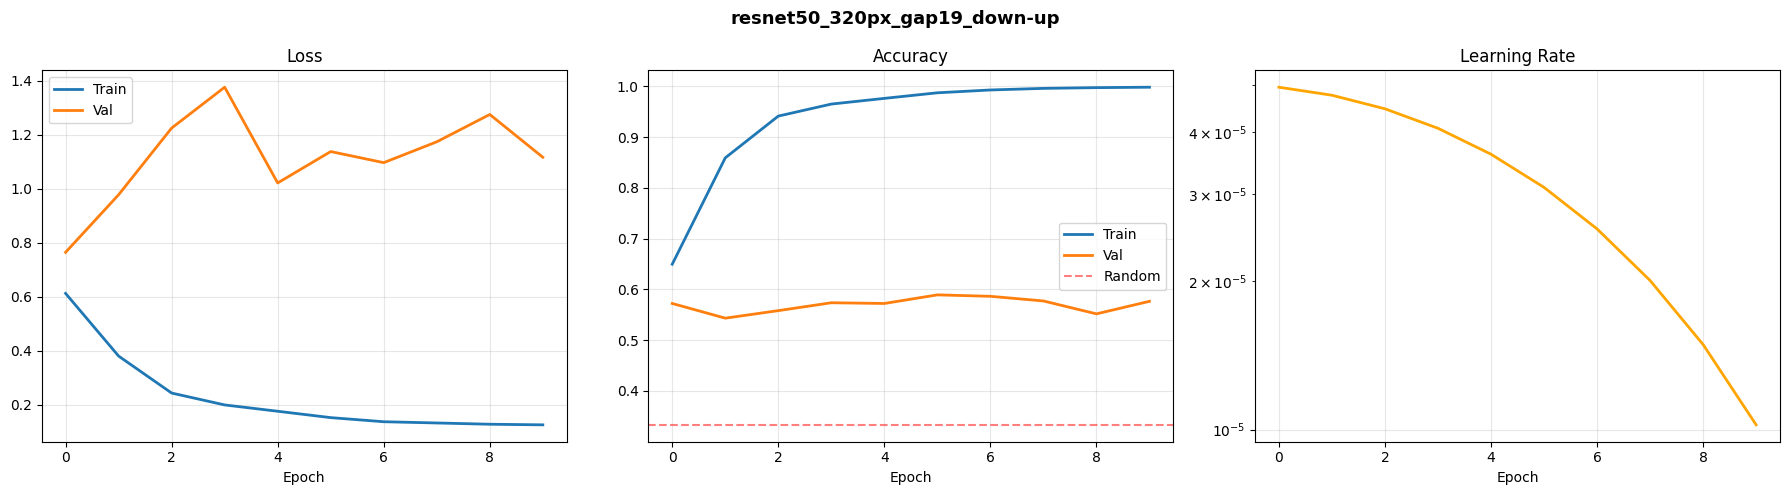

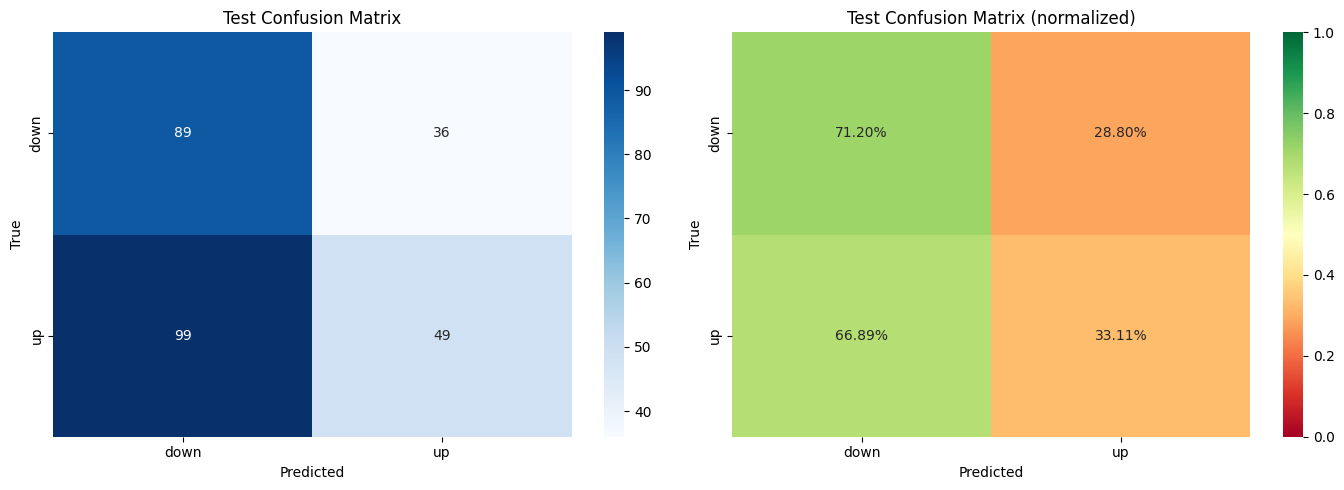

,precision,recall,f1-score,support
down,0.473404,0.712000,0.568690,125.000000
up,0.576471,0.331081,0.420601,148.000000
accuracy,0.505495,0.505495,0.505495,0.505495
macro avg,0.524937,0.521541,0.494645,273.000000
weighted avg,0.529279,0.505495,0.488407,273.000000


In [8]:
train_cfg = TrainConfig(
    data_root='/kaggle/input/stock-dataset/stock_dataset',
    metadata_csv=str(csv_path),
    model_family='resnet50',
    class_names=('down', 'up'),
    image_size=320,
    batch_size=32,
    epochs=14,
    patience=4,
    purge_gap=19,
)
report = train_model(train_cfg)
plot_history(report)
plot_confusion(report)
pd.DataFrame(report['test']['classification_report']).T

## Train DeiT On The Same Metadata

Use this after the ResNet run. If GPU memory is tight, lower `batch_size` to `8`.


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


pytorch_model.bin:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: facebook/deit-base-patch16-224
Key               | Status   |                                                                                        
------------------+----------+----------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([2, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([2])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

[01/12] train_acc=0.5458 val_acc=0.5469 train_f1=0.5454 val_f1=0.5308 lr=2.95e-05
[02/12] train_acc=0.6795 val_acc=0.5547 train_f1=0.6794 val_f1=0.5546 lr=2.81e-05
[03/12] train_acc=0.8286 val_acc=0.5625 train_f1=0.8286 val_f1=0.5415 lr=2.58e-05
[04/12] train_acc=0.9162 val_acc=0.5236 train_f1=0.9162 val_f1=0.4833 lr=2.28e-05
[05/12] train_acc=0.9668 val_acc=0.5074 train_f1=0.9668 val_f1=0.5030 lr=1.93e-05
[06/12] train_acc=0.9866 val_acc=0.5349 train_f1=0.9866 val_f1=0.5013 lr=1.55e-05
[07/12] train_acc=0.9913 val_acc=0.5286 train_f1=0.9913 val_f1=0.5199 lr=1.17e-05
Early stopping at epoch 7
Saved summary to /kaggle/working/candlestick_runs/deit_224px_gap19_down-up_summary.json


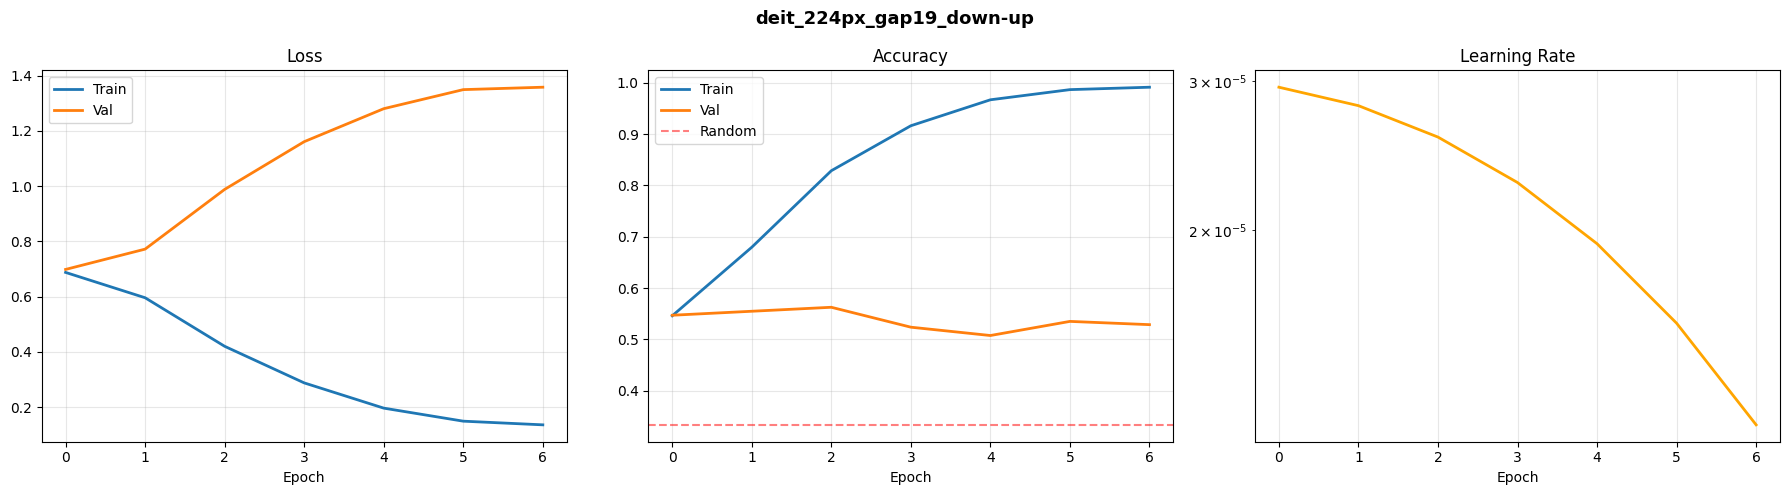

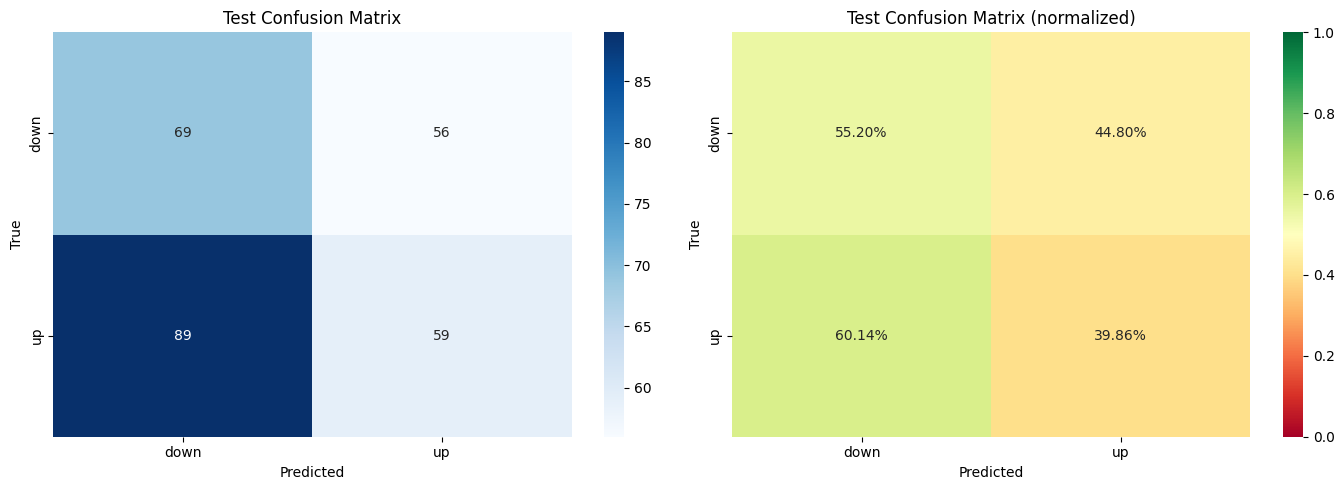

,precision,recall,f1-score,support
down,0.436709,0.552000,0.487633,125.000000
up,0.513043,0.398649,0.448669,148.000000
accuracy,0.468864,0.468864,0.468864,0.468864
macro avg,0.474876,0.475324,0.468151,273.000000
weighted avg,0.478092,0.468864,0.466510,273.000000


In [9]:
vit_cfg = TrainConfig(
    data_root='/kaggle/input/stock-dataset/stock_dataset',
    metadata_csv=str(csv_path),
    model_family='deit',
    vit_checkpoint='facebook/deit-base-patch16-224',
    class_names=('down', 'up'),
    image_size=224,
    batch_size=16,
    epochs=12,
    patience=4,
    lr_backbone=3e-5,
    lr_head=2e-4,
    purge_gap=19,
)
vit_report = train_model(vit_cfg)
plot_history(vit_report)
plot_confusion(vit_report)
pd.DataFrame(vit_report['test']['classification_report']).T

## Alternative Recipe: Quantile Labels

If `binary_fixed` still underperforms, try balanced top/bottom quantile labels.


In [10]:
quant_cfg = SignalConfig(
    data_root='/kaggle/input/datasets/romromkankane/stock-dataset/stock_dataset',
    output_csv='/kaggle/working/metadata_binary_quantile.csv',
    label_mode='binary_quantile',
    quantile=0.35,
    lookahead_days=1,
    purge_gap=19,
)
csv_path_q, summary_path_q = save_signal_metadata(quant_cfg)
print(csv_path_q)
pd.read_csv(csv_path_q)['label'].value_counts()

/kaggle/working/metadata_binary_quantile.csv


label
up      5933
down    5406
Name: count, dtype: int64

## Evaluation & Analysis

This section summarizes Accuracy, Precision, Recall, and F1-score, then shows sample predictions and misclassification patterns on the test set.


,run_name,val_acc,val_f1,test_acc,test_f1
0,resnet50_320px_gap19_down-up,0.589273,0.554668,0.505495,0.494645
1,deit_224px_gap19_down-up,0.562456,0.541491,0.468864,0.468151


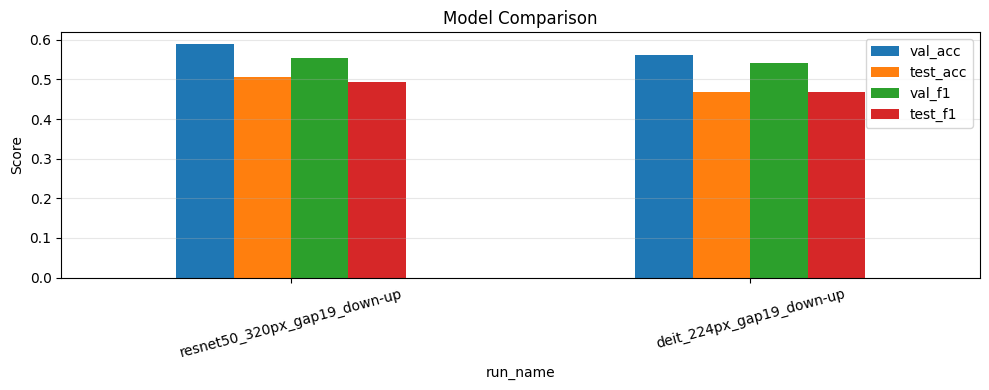

In [11]:
import matplotlib.pyplot as plt

eval_table = compare_reports([report, vit_report])
display(eval_table)

ax = eval_table.set_index('run_name')[['val_acc', 'test_acc', 'val_f1', 'test_f1']].plot(kind='bar', figsize=(10, 4), rot=15)
ax.set_title('Model Comparison')
ax.set_ylabel('Score')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
import math
import numpy as np
import pandas as pd
import torch
from PIL import Image

def load_checkpointed_model(checkpoint_path, device=None):
    checkpoint = torch.load(checkpoint_path, map_location=device or krvb.get_device())
    config = krvb.TrainConfig(**checkpoint["config"])
    class_names = list(checkpoint.get("class_names") or (config.class_names or krvb.DEFAULT_CLASS_ORDER))
    resolved_device = device or krvb.get_device()
    model = krvb.build_model(config, resolved_device, num_classes=len(class_names), class_names=class_names)
    model.load_state_dict(checkpoint["model_state"])
    model.eval()
    return model, config, class_names, checkpoint

def build_eval_frame(config):
    metadata_df = krvb.load_metadata(config)
    return krvb.prepare_split_df(metadata_df, config)

def select_examples(frame, class_names, per_class=1, seed=42):
    parts = []
    for label in class_names:
        subset = frame[frame["label"] == label]
        if not subset.empty:
            parts.append(subset.sample(n=min(per_class, len(subset)), random_state=seed))
    return pd.concat(parts, ignore_index=True).reset_index(drop=True)

@torch.no_grad()
def predict_examples(model, frame, config, class_names, sample_size=12, seed=42):
    sample = frame.sample(n=min(sample_size, len(frame)), random_state=seed).copy()
    _, eval_tf = krvb.build_transforms(config)
    device = next(model.parameters()).device
    rows = []
    for _, row in sample.iterrows():
        image = Image.open(row["resolved_path"]).convert("RGB")
        tensor = eval_tf(image)
        probs, pred_idx, _ = krvb._predict_tensor(model, tensor, config, device=device)
        rows.append({
            "image_path": row["image_path"],
            "resolved_path": row["resolved_path"],
            "stock": row["stock"],
            "timestamp": row["timestamp"],
            "true_label": row["label"],
            "pred_label": class_names[pred_idx],
            "confidence": float(probs[pred_idx]),
            "correct": bool(class_names[pred_idx] == row["label"]),
            "probabilities": probs.tolist(),
        })
    return pd.DataFrame(rows)

def summarize_prediction_errors(pred_df):
    return (
        pred_df.groupby(["true_label", "pred_label"], dropna=False)
        .agg(count=("correct", "size"), avg_confidence=("confidence", "mean"))
        .reset_index()
        .sort_values(["count", "avg_confidence"], ascending=[False, False])
    )

def plot_prediction_grid(pred_df, title, n=8, cols=4):
    import matplotlib.pyplot as plt

    sample = pred_df.head(n).reset_index(drop=True)
    rows = math.ceil(len(sample) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(4.5 * cols, 4.5 * rows))
    axes = np.atleast_1d(axes).reshape(rows, cols)

    for ax in axes.ravel():
        ax.axis("off")

    for ax, (_, row) in zip(axes.ravel(), sample.iterrows()):
        image = Image.open(row["resolved_path"]).convert("RGB")
        ax.imshow(image)
        color = "green" if row["correct"] else "red"
        ax.set_title(f"T:{row['true_label']} P:{row['pred_label']}\n{row['confidence']:.3f}", color=color, fontsize=10)
        ax.axis("off")

    fig.suptitle(title, fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


In [15]:
@torch.no_grad()
def predict_examples(model, frame, config, class_names, sample_size=12, seed=42):
    sample = frame.sample(n=min(sample_size, len(frame)), random_state=seed).copy()
    _, eval_tf = krvb.build_transforms(config)
    device = next(model.parameters()).device
    rows = []

    model.eval()
    for _, row in sample.iterrows():
        image = Image.open(row["resolved_path"]).convert("RGB")
        tensor = eval_tf(image).unsqueeze(0).to(device)

        if config.model_family == "deit":
            logits = model(pixel_values=tensor).logits
        else:
            logits = model(tensor)

        probs = logits.softmax(dim=1)[0].detach().cpu().numpy()
        pred_idx = int(probs.argmax())

        rows.append({
            "image_path": row["image_path"],
            "resolved_path": row["resolved_path"],
            "stock": row["stock"],
            "timestamp": row["timestamp"],
            "true_label": row["label"],
            "pred_label": class_names[pred_idx],
            "confidence": float(probs[pred_idx]),
            "correct": bool(class_names[pred_idx] == row["label"]),
            "probabilities": probs.tolist(),
        })

    return pd.DataFrame(rows)


,stock,timestamp,true_label,pred_label,confidence,correct
0,APLAPOLLO,2026-04-01 15:15:00+05:30,down,up,0.557495,False
1,IRCON,2026-03-30 14:15:00+05:30,up,down,0.797610,False
2,COFORGE,2026-04-01 13:15:00+05:30,up,up,0.632452,True
3,ROUTE,2026-03-30 13:15:00+05:30,up,up,0.872864,True
4,ROUTE,2026-03-30 14:15:00+05:30,up,down,0.948319,False
5,LAURUSLABS,2026-03-30 11:15:00+05:30,up,down,0.876633,False
6,ROUTE,2026-03-30 12:15:00+05:30,up,down,0.964052,False
7,AUBANK,2026-03-30 15:15:00+05:30,up,down,0.977837,False
8,TATAELXSI,2026-04-01 14:15:00+05:30,up,up,0.893822,True
9,TANLA,2026-04-01 09:15:00+05:30,up,up,0.549402,True


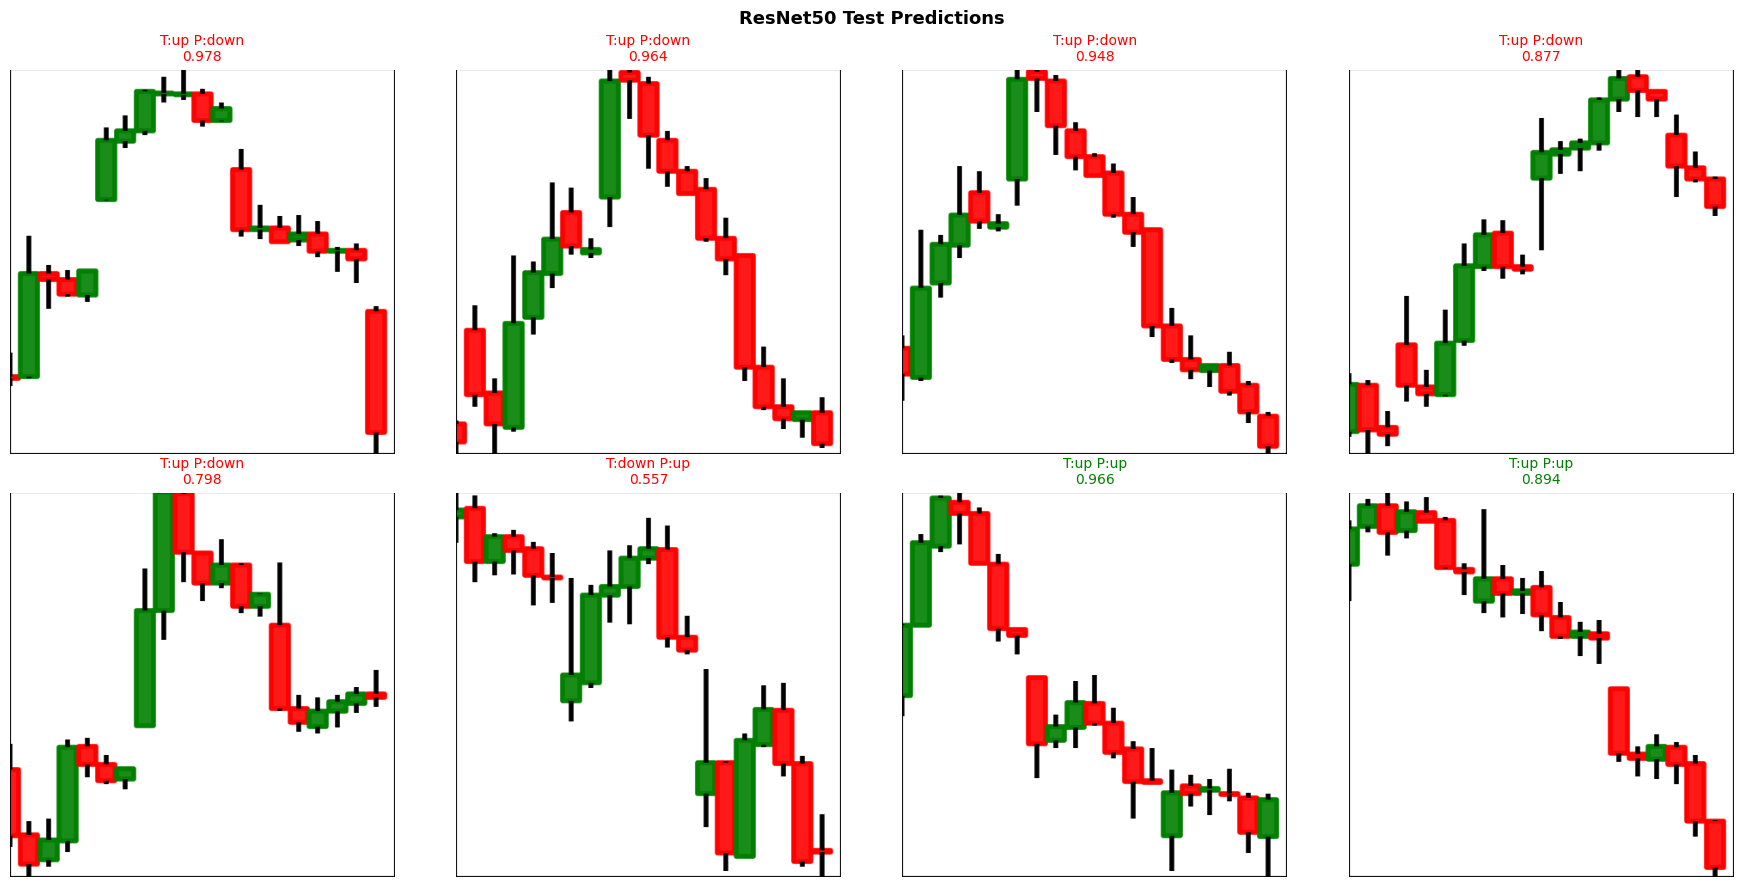

,true_label,pred_label,count,avg_confidence
2,up,down,5,0.912890
3,up,up,5,0.782915
0,down,down,1,0.777217
1,down,up,1,0.557495


In [17]:
resnet_model, resnet_config, resnet_class_names, _ = load_checkpointed_model(report['checkpoint_path'])
resnet_eval_df = build_eval_frame(resnet_config)
resnet_test_df = resnet_eval_df[resnet_eval_df['split'] == 'test'].reset_index(drop=True)
resnet_pred_df = predict_examples(resnet_model, resnet_test_df, resnet_config, resnet_class_names, sample_size=12, seed=42)

display(resnet_pred_df[['stock', 'timestamp', 'true_label', 'pred_label', 'confidence', 'correct']])
plot_prediction_grid(
    resnet_pred_df.sort_values(['correct', 'confidence'], ascending=[True, False]),
    title='ResNet50 Test Predictions',
    n=8,
    cols=4,
)
display(summarize_prediction_errors(resnet_pred_df))

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: facebook/deit-base-patch16-224
Key               | Status   |                                                                                        
------------------+----------+----------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([2, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([2])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.
Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


,stock,timestamp,true_label,pred_label,confidence,correct
0,APLAPOLLO,2026-04-01 15:15:00+05:30,down,down,0.599520,True
1,IRCON,2026-03-30 14:15:00+05:30,up,down,0.569364,False
2,COFORGE,2026-04-01 13:15:00+05:30,up,down,0.655851,False
3,ROUTE,2026-03-30 13:15:00+05:30,up,down,0.924867,False
4,ROUTE,2026-03-30 14:15:00+05:30,up,down,0.917382,False
5,LAURUSLABS,2026-03-30 11:15:00+05:30,up,down,0.610147,False
6,ROUTE,2026-03-30 12:15:00+05:30,up,up,0.764688,True
7,AUBANK,2026-03-30 15:15:00+05:30,up,up,0.676481,True
8,TATAELXSI,2026-04-01 14:15:00+05:30,up,down,0.900014,False
9,TANLA,2026-04-01 09:15:00+05:30,up,down,0.529196,False


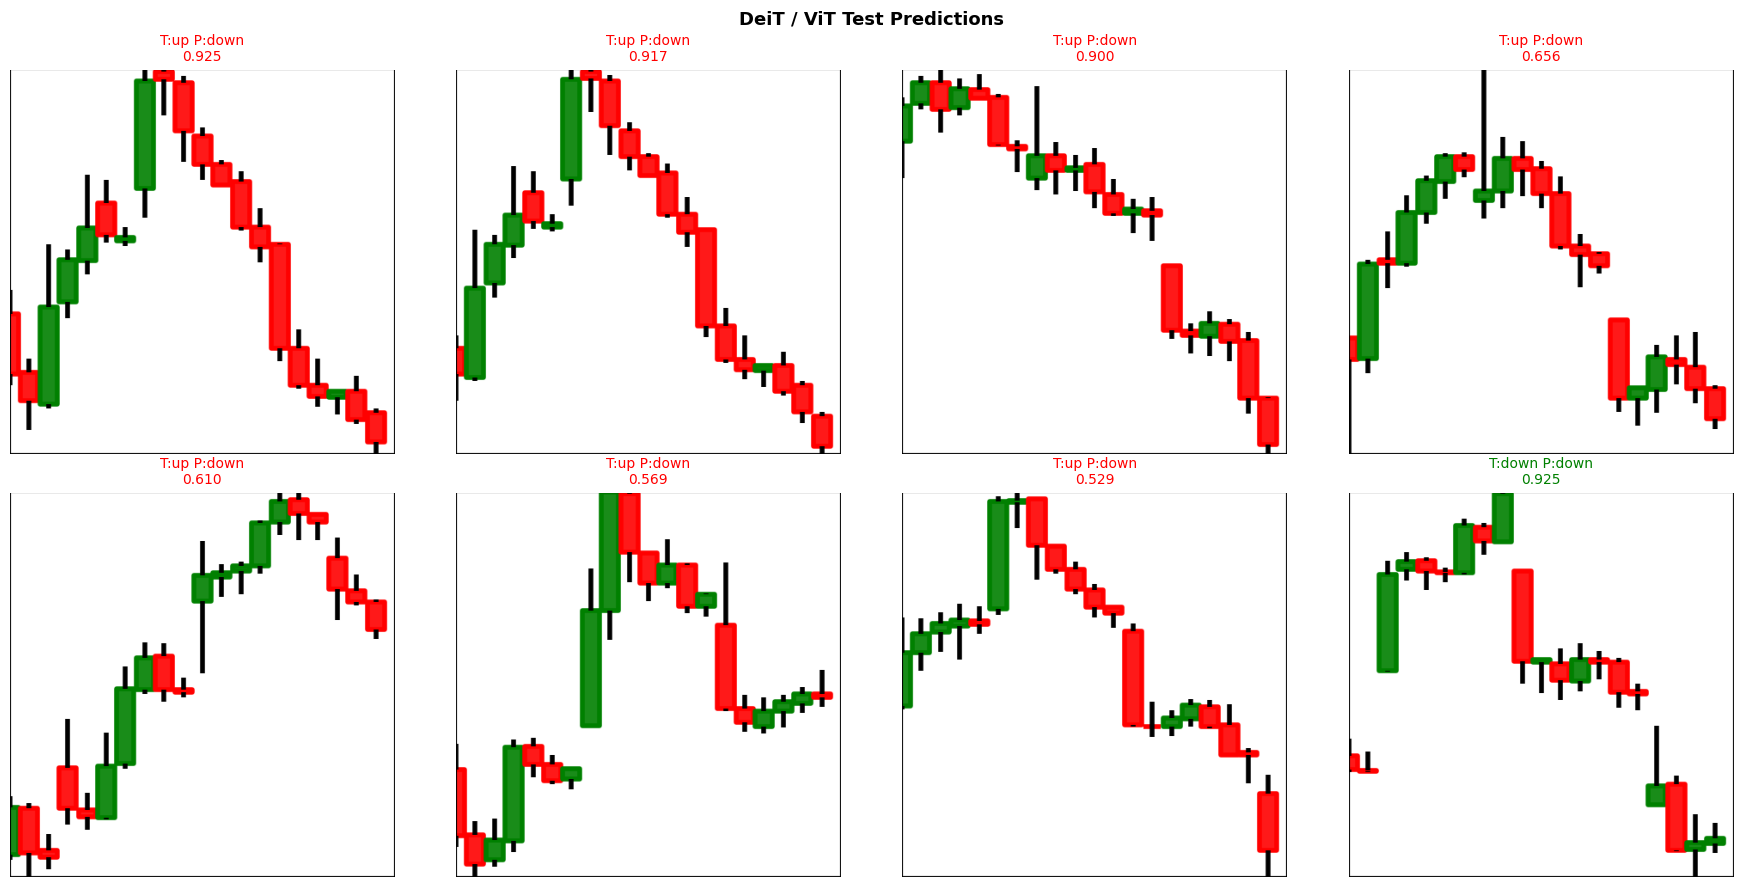

,true_label,pred_label,count,avg_confidence
1,up,down,7,0.729546
2,up,up,3,0.733632
0,down,down,2,0.762244


In [20]:
vit_model, vit_config, vit_class_names, _ = load_checkpointed_model(vit_report['checkpoint_path'])
vit_eval_df = build_eval_frame(vit_config)
vit_test_df = vit_eval_df[vit_eval_df['split'] == 'test'].reset_index(drop=True)
vit_pred_df = predict_examples(vit_model, vit_test_df, vit_config, vit_class_names, sample_size=12, seed=42)

display(vit_pred_df[['stock', 'timestamp', 'true_label', 'pred_label', 'confidence', 'correct']])
plot_prediction_grid(
    vit_pred_df.sort_values(['correct', 'confidence'], ascending=[True, False]),
    title='DeiT / ViT Test Predictions',
    n=8,
    cols=4,
)
display(summarize_prediction_errors(vit_pred_df))

### Pattern Analysis

- The most useful predictions are the high-confidence correct cases, because they show which candlestick formations the model learned consistently.
- The error tables help identify where the model confuses similar movement regimes, which usually happens around small trend changes and low-signal candles.
- Use these plots together with the XAI section to check whether the model is focusing on candle bodies, wicks, and recent trend structure instead of background pixels.


## Explainability (XAI)

This section visualizes which regions of the candlestick chart influenced the trained models. ResNet50 is explained with Grad-CAM, while DeiT/ViT is explained with last-layer attention maps.


In [21]:
from pathlib import Path
import pandas as pd

xai_dir = Path('/kaggle/working/xai_outputs')
xai_dir.mkdir(parents=True, exist_ok=True)
print(xai_dir)

/kaggle/working/xai_outputs


In [22]:
resnet_model, resnet_config, resnet_class_names, resnet_checkpoint = load_checkpointed_model(report['checkpoint_path'])
resnet_eval_df = build_eval_frame(resnet_config)
resnet_test_df = resnet_eval_df[resnet_eval_df['split'] == 'test'].reset_index(drop=True)
resnet_examples = select_examples(resnet_test_df, resnet_class_names, per_class=1, seed=42)
print(report['checkpoint_path'])
display(resnet_examples[['stock', 'timestamp', 'label', 'image_path']])

/kaggle/working/candlestick_runs/resnet50_320px_gap19_down-up.pt


,stock,timestamp,label,image_path
0,APLAPOLLO,2026-04-01 09:15:00+05:30,down,/content/drive/MyDrive/stock_dataset/raw_image...
1,RVNL,2026-03-30 13:15:00+05:30,up,/content/drive/MyDrive/stock_dataset/raw_image...


In [24]:
import math
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image

def _get_resnet_target_layer(model):
    return model.layer4[-1].conv3

def _get_deit_attention_target(model):
    encoder = getattr(model, "deit", None) or getattr(model, "vit", None)
    last_block = encoder.encoder.layer[-1]
    return last_block.attention.attention

class _GradCAMHook:
    def __init__(self, layer):
        self.activations = None
        self.gradients = None
        self.fwd = layer.register_forward_hook(self._forward_hook)
        self.bwd = layer.register_full_backward_hook(self._backward_hook)

    def _forward_hook(self, module, inputs, output):
        self.activations = output.detach()

    def _backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def close(self):
        self.fwd.remove()
        self.bwd.remove()

def _overlay_heatmap(image, heatmap, alpha=0.45, cmap="jet"):
    import matplotlib.cm as cm
    image_arr = np.asarray(image).astype(np.float32) / 255.0
    heatmap = np.clip(heatmap, 0, 1)
    heatmap = np.array(Image.fromarray((heatmap * 255).astype(np.uint8)).resize(image.size))
    heatmap = heatmap / 255.0
    colored = cm.get_cmap(cmap)(heatmap)[..., :3]
    return np.clip((1 - alpha) * image_arr + alpha * colored, 0, 1)

def generate_gradcam(model, image_tensor, config):
    device = next(model.parameters()).device
    hook = _GradCAMHook(_get_resnet_target_layer(model))
    try:
        model.zero_grad(set_to_none=True)
        x = image_tensor.unsqueeze(0).to(device)
        logits = model(x)
        probs = logits.softmax(dim=1)[0].detach().cpu().numpy()
        pred_idx = int(probs.argmax())
        logits[:, pred_idx].sum().backward()

        weights = hook.gradients.mean(dim=(2, 3), keepdim=True)
        cam = torch.sum(weights * hook.activations, dim=1)
        cam = torch.relu(cam)
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)
        return cam[0].cpu().numpy(), probs, pred_idx
    finally:
        hook.close()

def generate_deit_attention_map(model, image_tensor, config):
    device = next(model.parameters()).device
    x = image_tensor.unsqueeze(0).to(device)

    try:
        outputs = model(pixel_values=x, output_attentions=True, return_dict=True)
        probs = outputs.logits.softmax(dim=1)[0].detach().cpu().numpy()
        pred_idx = int(probs.argmax())
        if outputs.attentions is not None:
            attn = outputs.attentions[-1][0].mean(dim=0)
            cls_attn = attn[0, 1:]
        else:
            raise RuntimeError
    except Exception:
        captured = {}

        def _hook(module, inputs, output):
            if isinstance(output, tuple) and len(output) >= 2 and output[1] is not None:
                captured["attn"] = output[1].detach()

        handle = _get_deit_attention_target(model).register_forward_hook(_hook)
        try:
            outputs = model(pixel_values=x, return_dict=True)
            probs = outputs.logits.softmax(dim=1)[0].detach().cpu().numpy()
            pred_idx = int(probs.argmax())
        finally:
            handle.remove()

        if "attn" not in captured:
            raise RuntimeError("Could not extract DeiT attentions.")
        attn = captured["attn"][0].mean(dim=0)
        cls_attn = attn[0, 1:]

    grid = int(math.sqrt(cls_attn.numel()))
    heatmap = cls_attn.reshape(grid, grid).cpu().numpy()
    heatmap = heatmap - heatmap.min()
    heatmap = heatmap / (heatmap.max() + 1e-8)
    return heatmap, probs, pred_idx

def plot_xai_triplet(image_path, model, config, class_names, title, method="gradcam"):
    image = Image.open(image_path).convert("RGB")
    _, eval_tf = krvb.build_transforms(config)
    image_tensor = eval_tf(image)

    if method == "gradcam":
        heatmap, probs, pred_idx = generate_gradcam(model, image_tensor, config)
        label_name = "Grad-CAM"
    else:
        heatmap, probs, pred_idx = generate_deit_attention_map(model, image_tensor, config)
        label_name = "Attention"

    overlay = _overlay_heatmap(image, heatmap)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].imshow(image)
    axes[0].set_title("Original")
    axes[1].imshow(overlay)
    axes[1].set_title(label_name)
    axes[2].imshow(image)
    axes[2].set_title(f"Pred: {class_names[pred_idx]} | P={probs[pred_idx]:.3f}")
    for ax in axes:
        ax.axis("off")
    fig.suptitle(title, fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

    return {"pred_idx": pred_idx, "probs": probs}


/tmp/ipykernel_55/2795630730.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colored = cm.get_cmap(cmap)(heatmap)[..., :3]


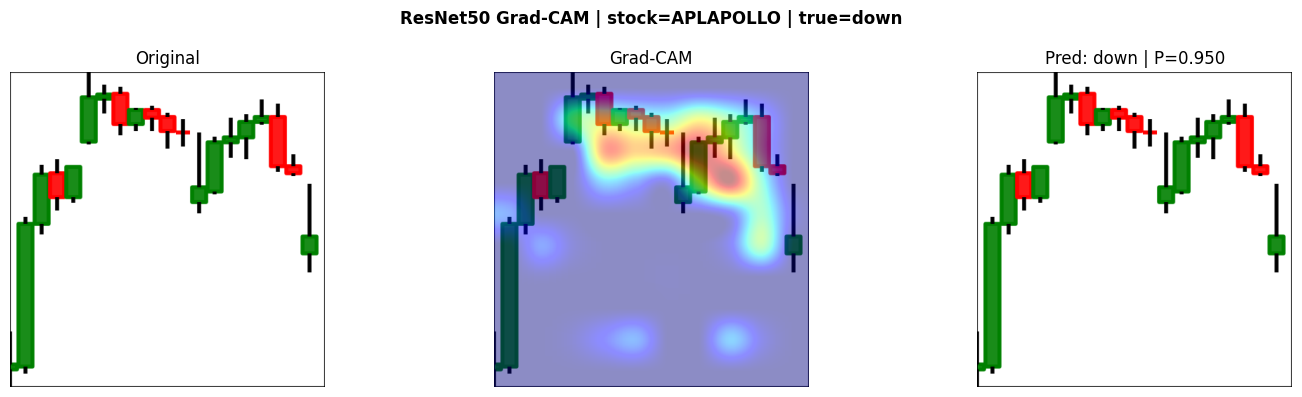

true=down pred=down probs=[0.9496271  0.05037288]


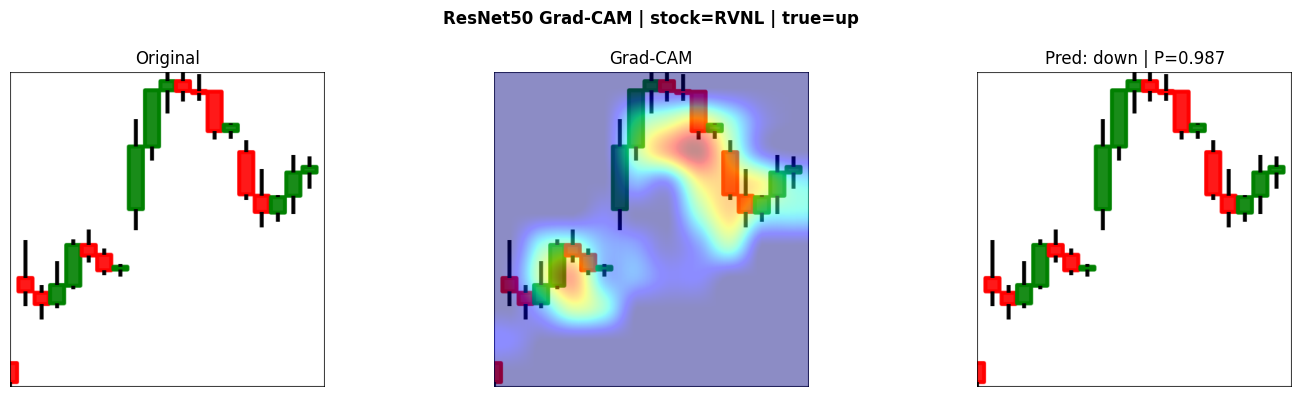

true=up pred=down probs=[0.98731416 0.01268589]


In [26]:
for _, row in resnet_examples.iterrows():
    result = plot_xai_triplet(
        row['resolved_path'],
        resnet_model,
        resnet_config,
        resnet_class_names,
        title=f"ResNet50 Grad-CAM | stock={row['stock']} | true={row['label']}",
        method='gradcam',
    )
    print(f"true={row['label']} pred={resnet_class_names[result['pred_idx']]} probs={result['probs']}")

In [27]:
vit_model, vit_config, vit_class_names, vit_checkpoint = load_checkpointed_model(vit_report['checkpoint_path'])
vit_eval_df = build_eval_frame(vit_config)
vit_test_df = vit_eval_df[vit_eval_df['split'] == 'test'].reset_index(drop=True)
vit_examples = select_examples(vit_test_df, vit_class_names, per_class=1, seed=42)
print(vit_report['checkpoint_path'])
display(vit_examples[['stock', 'timestamp', 'label', 'image_path']])

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: facebook/deit-base-patch16-224
Key               | Status   |                                                                                        
------------------+----------+----------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([2, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([2])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


/kaggle/working/candlestick_runs/deit_224px_gap19_down-up.pt


,stock,timestamp,label,image_path
0,APLAPOLLO,2026-04-01 09:15:00+05:30,down,/content/drive/MyDrive/stock_dataset/raw_image...
1,RVNL,2026-03-30 13:15:00+05:30,up,/content/drive/MyDrive/stock_dataset/raw_image...


In [31]:
import math
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image

def _overlay_heatmap(image, heatmap, alpha=0.45, cmap="jet"):
    import matplotlib.cm as cm
    image_arr = np.asarray(image).astype(np.float32) / 255.0
    heatmap = np.clip(heatmap, 0, 1)
    heatmap = np.array(Image.fromarray((heatmap * 255).astype(np.uint8)).resize(image.size)) / 255.0
    colored = cm.get_cmap(cmap)(heatmap)[..., :3]
    return np.clip((1 - alpha) * image_arr + alpha * colored, 0, 1)

def _get_deit_last_block(model):
    encoder = getattr(model, "deit", None) or getattr(model, "vit", None)
    if encoder is None:
        raise ValueError("Could not find DeiT/ViT encoder.")
    return encoder.encoder.layer[-1]

def generate_deit_attention_map(model, image_tensor, config):
    device = next(model.parameters()).device
    x = image_tensor.unsqueeze(0).to(device)

    last_block = _get_deit_last_block(model)

    # Force eager attention when possible
    try:
        model.config._attn_implementation = "eager"
    except Exception:
        pass

    captured = {}

    def _capture_hidden(_module, _inputs, output):
        captured["hidden"] = output.detach()

    handle = last_block.layernorm_before.register_forward_hook(_capture_hidden)
    try:
        outputs = model(pixel_values=x, return_dict=True)
        probs = outputs.logits.softmax(dim=1)[0].detach().cpu().numpy()
        pred_idx = int(probs.argmax())
    finally:
        handle.remove()

    if "hidden" not in captured:
        raise RuntimeError("Could not capture transformer hidden states for attention map.")

    hidden = captured["hidden"]  # [batch, seq_len, hidden_size]
    sa = last_block.attention.attention

    q = sa.query(hidden)
    k = sa.key(hidden)

    batch_size, seq_len, _ = hidden.shape
    num_heads = sa.num_attention_heads
    head_dim = sa.attention_head_size

    q = q.view(batch_size, seq_len, num_heads, head_dim).transpose(1, 2)
    k = k.view(batch_size, seq_len, num_heads, head_dim).transpose(1, 2)

    attn_scores = torch.matmul(q, k.transpose(-1, -2)) * sa.scaling
    attn_probs = attn_scores.softmax(dim=-1)

    # Average heads, take CLS token attention to patch tokens
    cls_attn = attn_probs[0].mean(dim=0)[0, 1:]

    grid = int(math.sqrt(cls_attn.numel()))
    if grid * grid != cls_attn.numel():
        raise ValueError("Attention tokens do not form a square patch grid.")

    heatmap = cls_attn.reshape(grid, grid)
    heatmap = heatmap - heatmap.min()
    heatmap = heatmap / (heatmap.max() + 1e-8)
    return heatmap.detach().cpu().numpy(), probs, pred_idx


def plot_xai_triplet(image_path, model, config, class_names, title, method="gradcam"):
    image = Image.open(image_path).convert("RGB")
    _, eval_tf = krvb.build_transforms(config)
    image_tensor = eval_tf(image)

    if method == "gradcam":
        heatmap, probs, pred_idx = generate_gradcam(model, image_tensor, config)
        label_name = "Grad-CAM"
    else:
        heatmap, probs, pred_idx = generate_deit_attention_map(model, image_tensor, config)
        label_name = "Attention"

    overlay = _overlay_heatmap(image, heatmap)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].imshow(image)
    axes[0].set_title("Original")
    axes[1].imshow(overlay)
    axes[1].set_title(label_name)
    axes[2].imshow(image)
    axes[2].set_title(f"Pred: {class_names[pred_idx]} | P={probs[pred_idx]:.3f}")
    for ax in axes:
        ax.axis("off")
    fig.suptitle(title, fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

    return {"pred_idx": pred_idx, "probs": probs}


Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.
/tmp/ipykernel_55/1194549809.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colored = cm.get_cmap(cmap)(heatmap)[..., :3]


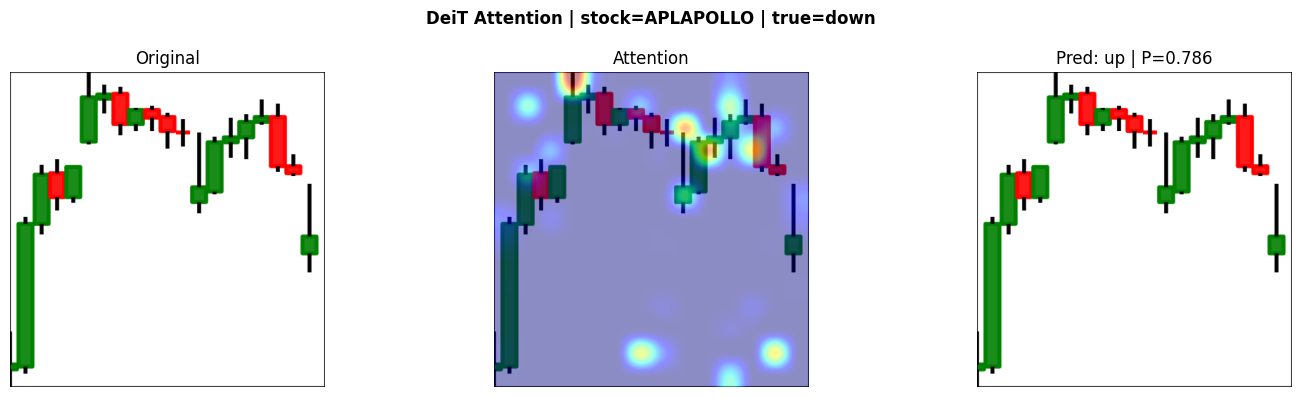

true=down pred=up probs=[0.2143563  0.78564364]


Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


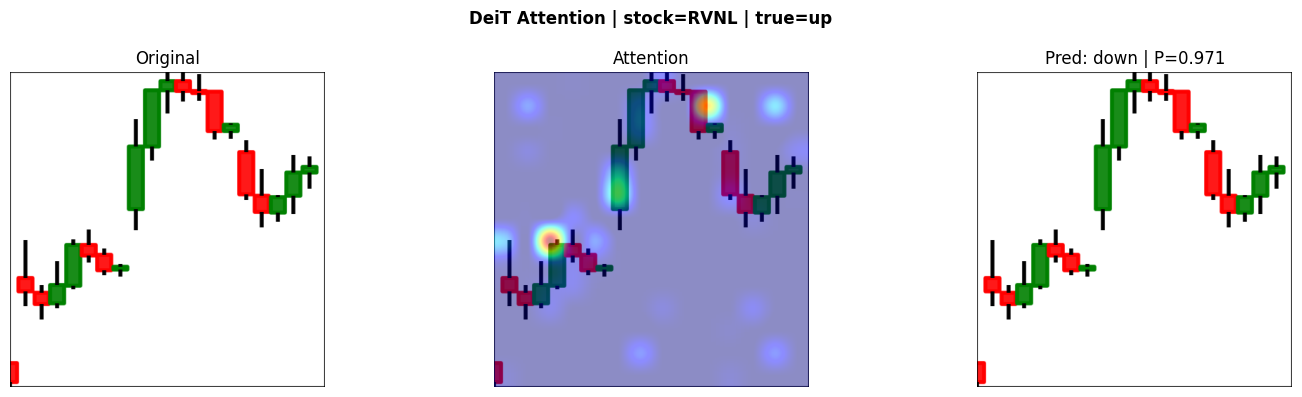

true=up pred=down probs=[0.9706006  0.02939941]


In [32]:
for _, row in vit_examples.iterrows():
    result = plot_xai_triplet(
        row['resolved_path'],
        vit_model,
        vit_config,
        vit_class_names,
        title=f"DeiT Attention | stock={row['stock']} | true={row['label']}",
        method='attention',
    )
    print(f"true={row['label']} pred={vit_class_names[result['pred_idx']]} probs={result['probs']}")

### How to read the XAI plots

- For Grad-CAM, the brighter regions indicate where ResNet focused most strongly when making the prediction.
- For attention maps, the highlighted patches show which chart regions the DeiT model attended to most strongly.
- In both cases, the goal is to verify whether the model is focusing on candle bodies, wicks, and recent trend structure rather than background pixels.


## Comparative Study

This project does not try to hard-code classic candlestick rules. Instead, the trained model learns a softer version of those ideas from data. That makes it possible to compare the learned behavior against well-known patterns such as Doji, Hammer, and Engulfing.


In [33]:
comparative_study = pd.DataFrame([
    {
        'Pattern': 'Doji',
        'Traditional interpretation': 'Indecision or balance between buyers and sellers',
        'Similarity to model': 'Both can react to weak momentum and uncertain reversal points',
        'Difference from model': 'The model also uses the surrounding trend and neighboring candles, not just body symmetry',
    },
    {
        'Pattern': 'Hammer',
        'Traditional interpretation': 'Potential bullish reversal after a decline',
        'Similarity to model': 'Both may pay attention to a long lower wick and price rejection',
        'Difference from model': 'The model can reject a Hammer if the broader sequence still looks weak',
    },
    {
        'Pattern': 'Engulfing',
        'Traditional interpretation': 'Stronger reversal or momentum shift',
        'Similarity to model': 'Both capture strong directional candles and body dominance',
        'Difference from model': 'The model learns from many examples and produces graded confidence rather than a strict rule',
    },
])
display(comparative_study)

print('Takeaway: the CNN/ViT model behaves like a data-driven extension of classical candlestick analysis.')
print('It can recover familiar ideas such as reversal and continuation, but it also incorporates broader context.')


,Pattern,Traditional interpretation,Similarity to model,Difference from model
0,Doji,Indecision or balance between buyers and sellers,Both can react to weak momentum and uncertain ...,The model also uses the surrounding trend and ...
1,Hammer,Potential bullish reversal after a decline,Both may pay attention to a long lower wick an...,The model can reject a Hammer if the broader s...
2,Engulfing,Stronger reversal or momentum shift,Both capture strong directional candles and bo...,The model learns from many examples and produc...


Takeaway: the CNN/ViT model behaves like a data-driven extension of classical candlestick analysis.
It can recover familiar ideas such as reversal and continuation, but it also incorporates broader context.
